# Blood Vessel Extraction & Structural Analysis

This notebook provides interactive inspection, step-by-step visualization, K-Fold cross-validation hyperparameter tuning, and structural anomaly/outlier detection of blood vessel extraction algorithms on the **Fundus-AVSeg** dataset (*Nature Scientific Data, 2025*).

### Pipeline Components:
1. **Local Adaptive Thresholding**: Gaussian local thresholding + morphological cleanup.
2. **Frangi Vesselness Filter**: Multi-scale Hessian-based vesselness filtering.
3. **K-Fold Cross-Validation**: Stratified parameter tuning to find optimal converging filter attributes.
4. **Structural Anomaly & Outlier Analysis**: IQR outlier detection on branch length, density, and orientation entropy.
5. **Disease-Aware Polar Rose Plots**: Sector-highlighted orientation distributions showing disease clustering.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io

from vessel_extraction import (
    load_split,
    load_image,
    load_annotation,
    annotation_to_binary_mask,
    get_disease_label,
    extract_green_channel,
    segment_adaptive_threshold,
    segment_frangi,
    evaluate_segmentation,
    compute_vessel_metrics,
    compute_branch_analysis,
    detect_branch_outliers,
    detect_image_outliers,
    plot_outlier_polar_rose,
    process_single_image,
    process_dataset,
    RESULTS_DIR
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Dataset Overview & Split Information
Inspect dataset splits (`training.txt` - 80 images, `testing.txt` - 20 images) and disease categories.

In [2]:
train_files = load_split('train')
test_files = load_split('test')

print(f"Training set size: {len(train_files)} images")
print(f"Testing set size:  {len(test_files)} images")

disease_counts = {}
for f in test_files:
    label = get_disease_label(f)
    disease_counts[label] = disease_counts.get(label, 0) + 1

print("\nTest set breakdown by disease:")
for disease, count in disease_counts.items():
    print(f" - {disease}: {count} images")

Training set size: 80 images
Testing set size:  20 images

Test set breakdown by disease:
 - Normal: 9 images
 - Glaucoma: 5 images
 - Age-Related Macular Degeneration: 2 images
 - Diabetic Retinopathy: 4 images


## 2. Sample Image & Ground Truth Annotation Inspection
Fundus-AVSeg multi-color annotations (Red=Arteries, Blue=Veins, Green=Crossings, White=Uncertain) converted to binary vessel mask.

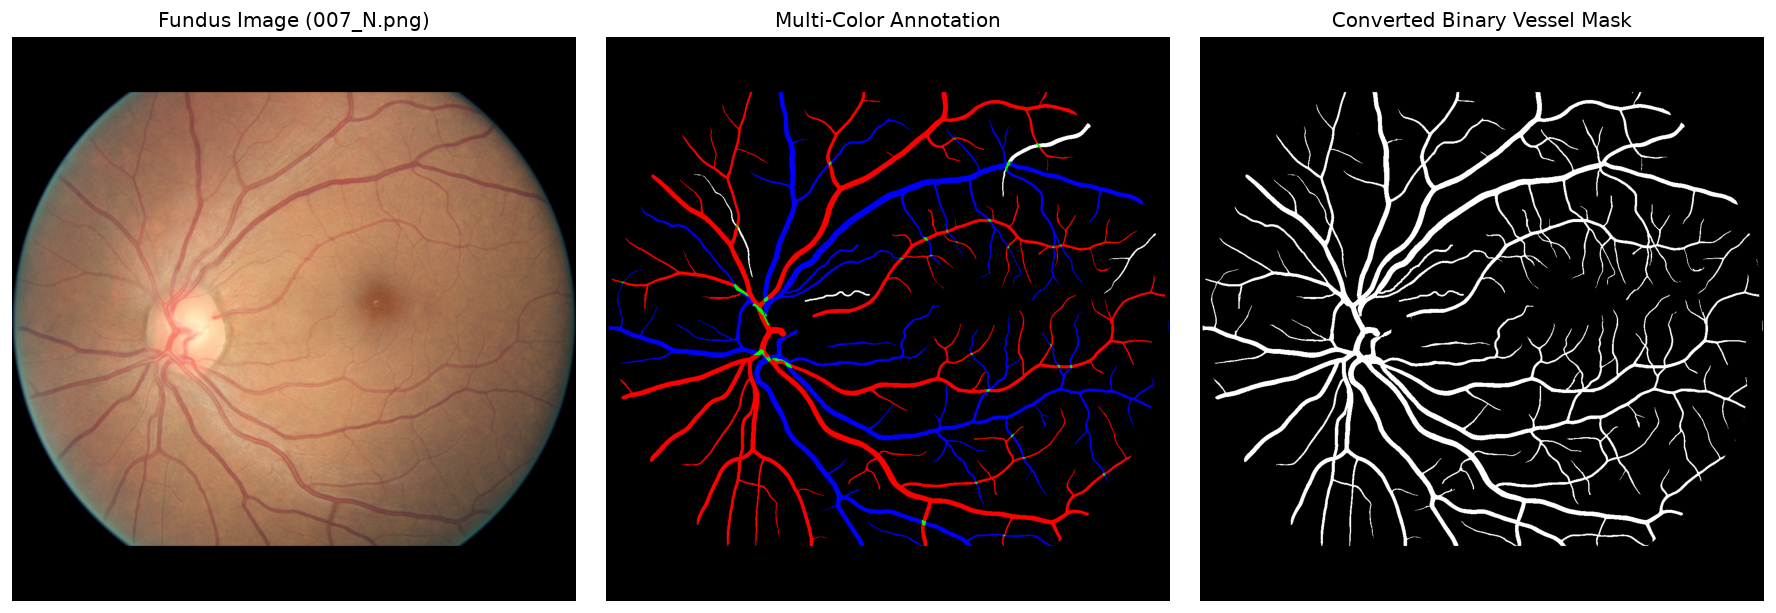

In [3]:
sample_file = test_files[0] if test_files else '035_A.png'
img = load_image(sample_file)
ann = load_annotation(sample_file)
gt_mask = annotation_to_binary_mask(ann)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title(f"Fundus Image ({sample_file})")
axes[0].axis('off')

if ann is not None:
    axes[1].imshow(ann)
    axes[1].set_title("Multi-Color Annotation")
    axes[1].axis('off')

if gt_mask is not None:
    axes[2].imshow(gt_mask, cmap='gray')
    axes[2].set_title("Converted Binary Vessel Mask")
    axes[2].axis('off')

plt.tight_layout()
plt.show()

## 3. Step-by-Step Segmentation Walkthrough
Demonstrate green channel extraction, Method 1 (Local Adaptive), and Method 2 (Frangi Filter).

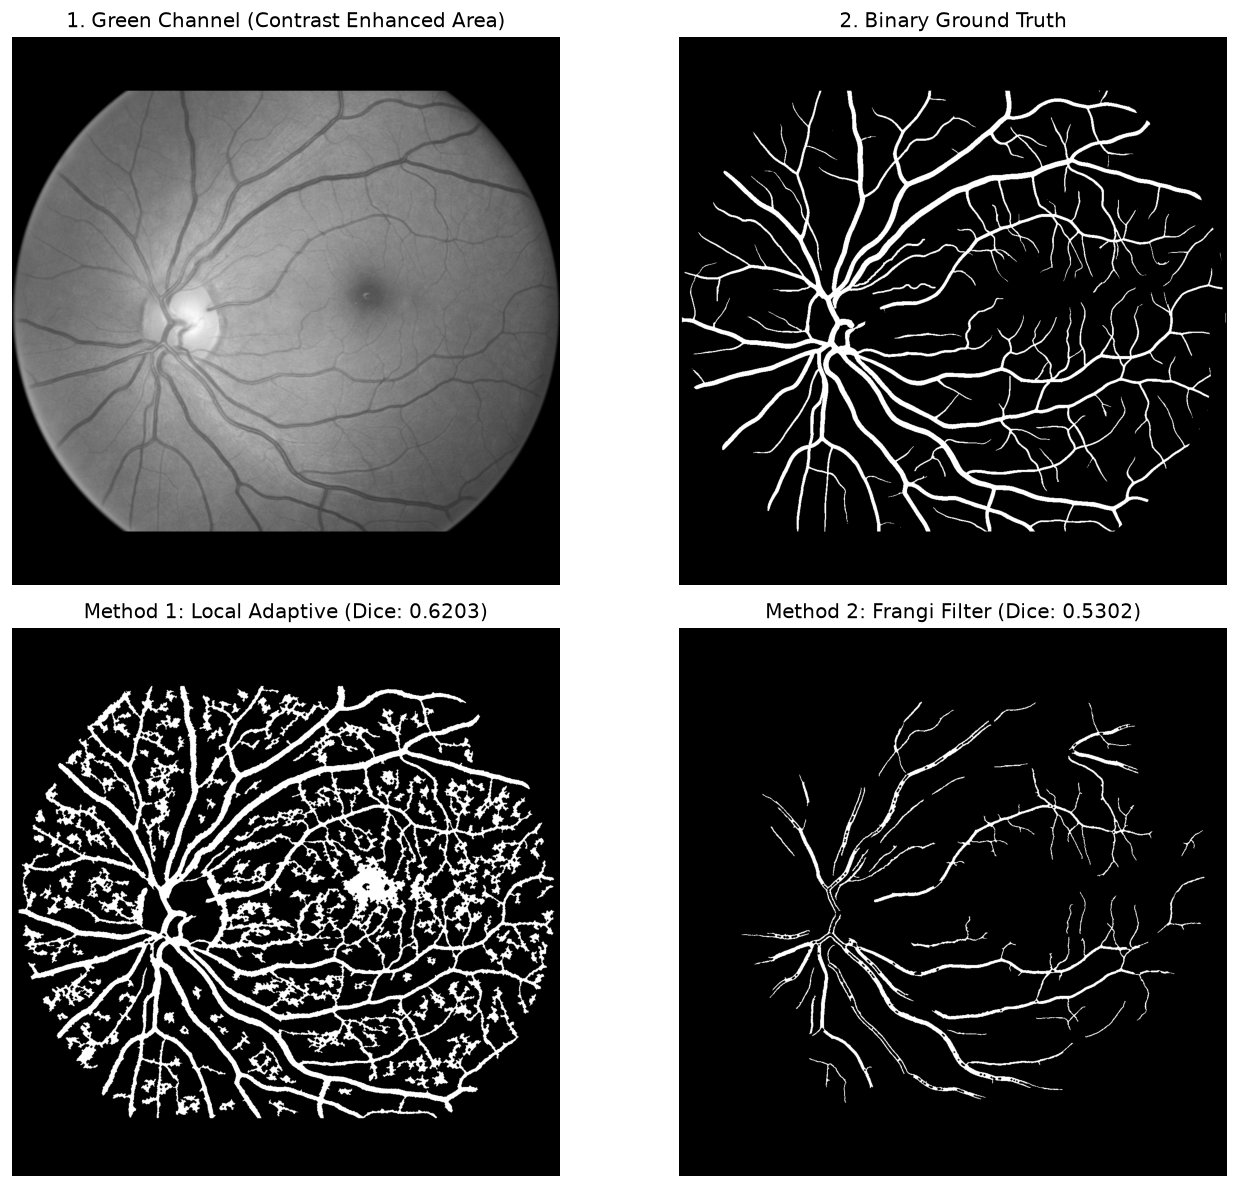

In [4]:
green = extract_green_channel(img)
m1_result = segment_adaptive_threshold(green)
m2_result = segment_frangi(green)

eval_m1 = evaluate_segmentation(m1_result, gt_mask)
eval_m2 = evaluate_segmentation(m2_result, gt_mask)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(green, cmap='gray')
axes[0, 0].set_title("1. Green Channel (Contrast Enhanced Area)")
axes[0, 0].axis('off')

axes[0, 1].imshow(gt_mask, cmap='gray')
axes[0, 1].set_title("2. Binary Ground Truth")
axes[0, 1].axis('off')

axes[1, 0].imshow(m1_result, cmap='gray')
axes[1, 0].set_title(f"Method 1: Local Adaptive (Dice: {eval_m1.get('dice', 0):.4f})")
axes[1, 0].axis('off')

axes[1, 1].imshow(m2_result, cmap='gray')
axes[1, 1].set_title(f"Method 2: Frangi Filter (Dice: {eval_m2.get('dice', 0):.4f})")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 4. K-Fold Cross-Validation Hyperparameter Search
Analyze K-Fold cross-validation results to find optimal filter parameters (`block_size`, `min_size`, `sigmas`, `alpha`, `beta`).

In [5]:
kfold_adaptive_path = os.path.join(RESULTS_DIR, 'kfold_adaptive.csv')
kfold_frangi_path = os.path.join(RESULTS_DIR, 'kfold_frangi.csv')

if os.path.exists(kfold_adaptive_path):
    df_k_adapt = pd.read_csv(kfold_adaptive_path)
    print("--- Top 5 Adaptive Threshold Parameter Configurations ---")
    display(df_k_adapt.sort_values('mean_dice', ascending=False).head(5))

if os.path.exists(kfold_frangi_path):
    df_k_frangi = pd.read_csv(kfold_frangi_path)
    print("\n--- Top 5 Frangi Filter Parameter Configurations ---")
    display(df_k_frangi.sort_values('mean_dice', ascending=False).head(5))

--- Top 5 Adaptive Threshold Parameter Configurations ---


,block_size,min_size,mean_dice,std_dice
20,201,500,0.020326,0.007731
21,201,1000,0.018314,0.007431
22,201,1500,0.015370,0.006782
23,201,2000,0.014054,0.006799
16,151,500,0.012244,0.005935



--- Top 5 Frangi Filter Parameter Configurations ---


,sigma_name,alpha,beta,mean_dice,std_dice
35,0.5-3,0.1,0.8,0.083812,0.032130
39,0.5-3,0.3,0.8,0.083812,0.032130
47,0.5-3,0.8,0.8,0.083812,0.032130
43,0.5-3,0.5,0.8,0.083812,0.032130
42,0.5-3,0.5,0.5,0.076026,0.029601


## 5. Vessel Structural Analysis & Network Graph
Extract vessel skeleton, measure vessel lengths, and map branch networks using `sknw`.

Total Thinned Vessel Length: 22058.04 pixels
Length of Wide Vessels (>15px): 5538.01 pixels
Length of Major Vessels (>40px): 0.00 pixels
Total Detected Branches: 555
Branch Density (per 1M px): 338.75
Orientation Entropy: 2.9098


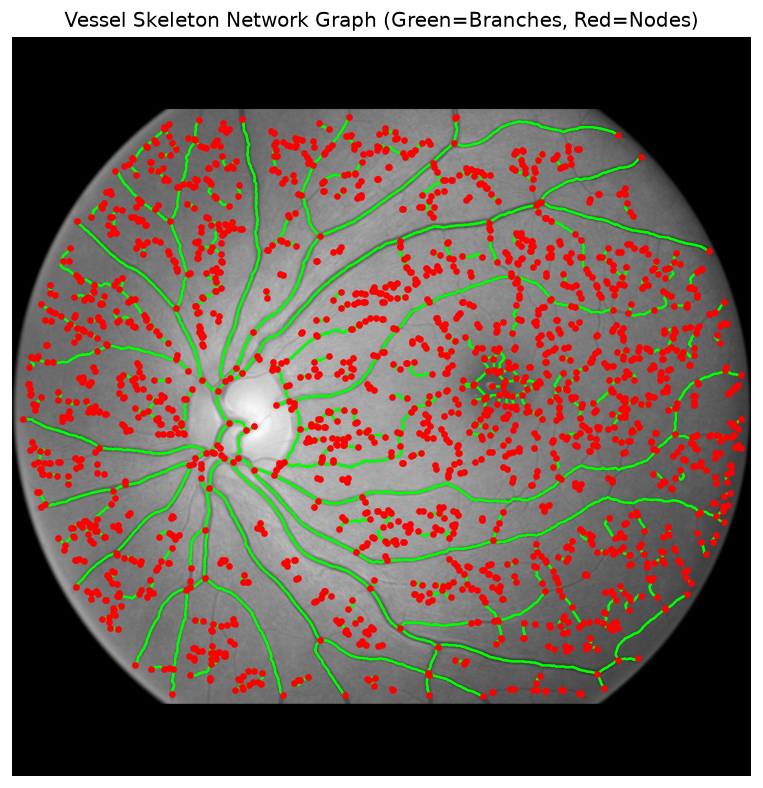

In [6]:
v_metrics = compute_vessel_metrics(m1_result)
thin_mask = v_metrics['thin_mask']
b_analysis = compute_branch_analysis(thin_mask, img_shape=img.shape)

print(f"Total Thinned Vessel Length: {v_metrics['thinned_length']:.2f} pixels")
print(f"Length of Wide Vessels (>15px): {v_metrics['length_width_gt_15']:.2f} pixels")
print(f"Length of Major Vessels (>40px): {v_metrics['length_width_gt_40']:.2f} pixels")
print(f"Total Detected Branches: {b_analysis['num_branches']}")
print(f"Branch Density (per 1M px): {b_analysis['branch_density']:.2f}")
print(f"Orientation Entropy: {b_analysis['orientation_entropy']:.4f}")

# Graph Visualization
graph = b_analysis['graph']
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(green, cmap='gray')

if graph is not None:
    for (s, e) in graph.edges():
        pts = graph[s][e]['pts']
        ax.plot(pts[:, 1], pts[:, 0], 'lime', linewidth=1.5)
        
    nodes = graph.nodes()
    ps = np.array([nodes[i]['o'] for i in nodes])
    if len(ps) > 0:
        ax.plot(ps[:, 1], ps[:, 0], 'red', marker='o', linestyle='', markersize=3)

ax.set_title("Vessel Skeleton Network Graph (Green=Branches, Red=Nodes)")
ax.axis('off')
plt.show()

## 6. Structural Outlier Detection & Disease Pathology Clustering
Detect statistical outliers on vessel branch length, branch density, and orientation entropy to identify disease-related vessel structural anomalies.

In [7]:
metrics_csv = os.path.join(RESULTS_DIR, 'metrics_test.csv')
if os.path.exists(metrics_csv):
    df_m = pd.read_csv(metrics_csv)
    df_m = detect_image_outliers(df_m)
    
    print("--- Dataset Outlier Analysis ---")
    display(df_m[['filename', 'disease', 'vessel_length', 'num_branches', 'branch_density', 'orientation_entropy', 'is_overall_outlier']])
    
    print("\n--- Disease Category Structural Feature Averages ---")
    disease_grp = df_m.groupby('disease')[['branch_density', 'orientation_entropy', 'vessel_length', 'm1_dice']].mean()
    display(disease_grp)

--- Dataset Outlier Analysis ---


,filename,disease,vessel_length,num_branches,branch_density,orientation_entropy,is_overall_outlier
0,007_N.png,Normal,2708.000000,75,45.776367,2.721147,False
1,016_N.png,Normal,2497.414214,163,99.487305,2.782401,False
2,018_N.png,Normal,2871.656854,184,34.777665,2.594827,False
3,022_N.png,Normal,936.000000,75,45.776367,2.779627,False
4,024_N.png,Normal,758.000000,34,20.751953,2.769562,False
5,027_G.png,Glaucoma,2884.242641,264,49.898389,2.618905,False
6,035_A.png,Age-Related Macular Degeneration,1466.000000,84,51.269531,2.790044,False
7,040_G.png,Glaucoma,907.000000,50,30.517578,2.756449,False
8,044_N.png,Normal,1819.828427,99,60.424805,2.677070,False
9,047_A.png,Age-Related Macular Degeneration,2044.414214,177,108.032227,2.601019,False



--- Disease Category Structural Feature Averages ---


,branch_density,orientation_entropy,vessel_length,m1_dice
disease,,,,
Age-Related Macular Degeneration,79.650879,2.695531,1755.207107,0.563510
Diabetic Retinopathy,61.592187,2.670880,2347.517767,0.600316
Glaucoma,49.774600,2.687619,1669.497056,0.577650
Normal,81.175383,2.742779,4646.706149,0.606172


## 7. Disease-Aware Outlier Polar Rose Plot
Highlight anomalous branch orientation clusters (red sectors) on polar rose plots.

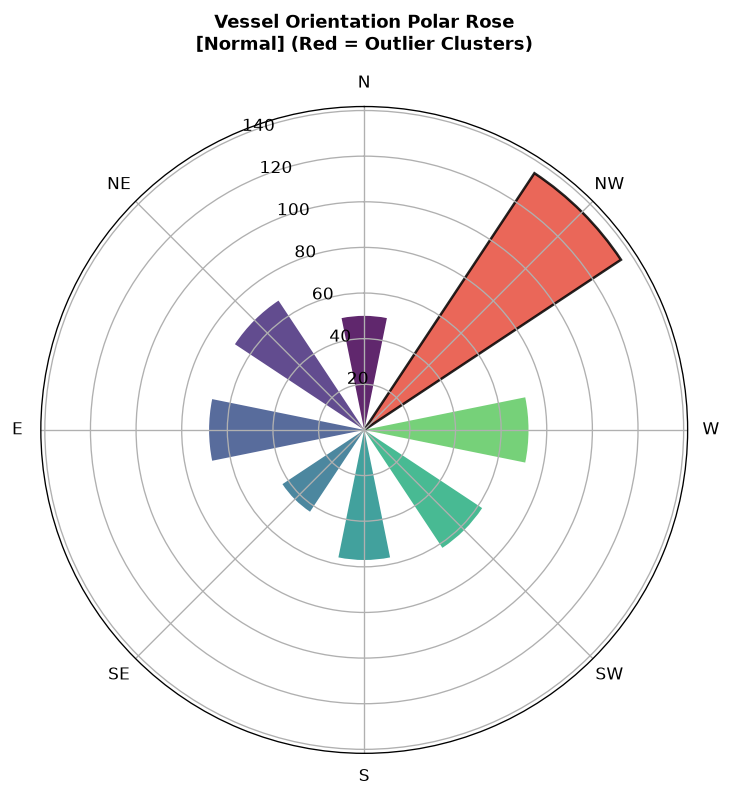

In [8]:
orientations = b_analysis['branch_orientations']
lengths = b_analysis['branch_lengths']
disease_lbl = get_disease_label(sample_file)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
plot_outlier_polar_rose(orientations, lengths, disease_label=disease_lbl, ax=ax)
plt.show()